### Signal detection theory: a noisy continuum
**Edit the numbers marked `👈` and press ▶ (or Shift+Enter) to re-run.**

What happens to the population-average distribution as you drop `n_neurons` to 1? Or raise the `baseline_rate`?

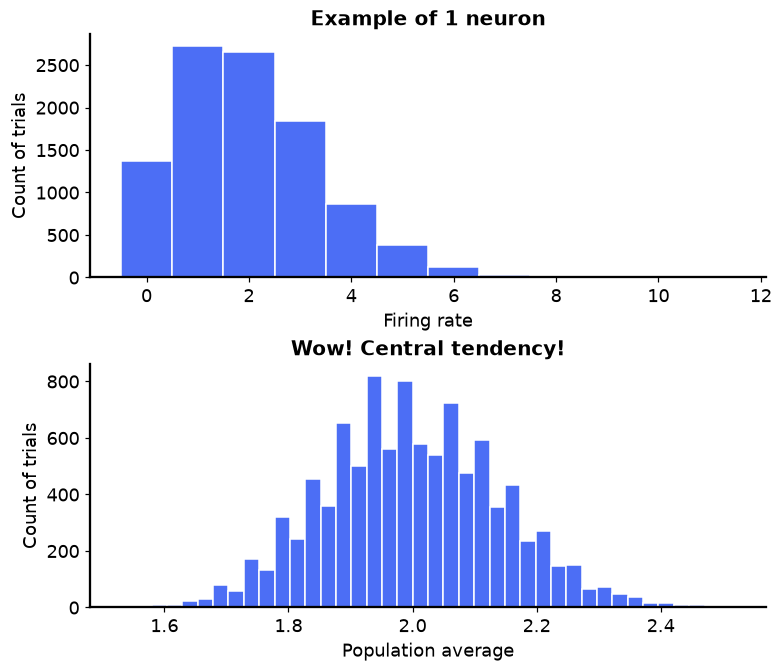

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

# A few plot-styling defaults (the Python version of makeMyPlotPretty)
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "legend.frameon": False,
})
BLUE = "#4c6ef5"

# ---- Edit these three numbers, then re-run the cell -------------------------
baseline_rate = 2       # 👈 spikes per second on a signal-absent trial
n_neurons     = 100     # 👈 how many neurons we average over
n_trials      = 10000   # 👈 how many signal-absent trials we simulate
# -----------------------------------------------------------------------------

# let's assume you have some neurons in V1 who have a baseline firing rate of
# a couple of spikes per second (realistically, this is probably much higher
# Niemeyer, & Paradiso, 2017; Albrecht, & Hamilton, 1982)
# Neural firing rates are probabilistic and can be described by a poisson
# distribution
# We sample firing rates from the neurons over many signal-absent trials
rng = np.random.default_rng()
firing_rates = rng.poisson(baseline_rate, size=(n_neurons, n_trials))  # sample a poisson distribution

# Let's say we read this out by taking the average firing rate as our
# estimate
est = firing_rates.mean(axis=0)  # the average on the first dimension - across neurons

# lets plot this
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), constrained_layout=True)

ax1.hist(firing_rates[0], bins=np.arange(firing_rates[0].max() + 2) - 0.5,
         color=BLUE, edgecolor="white")
ax1.set_xlabel("Firing rate")
ax1.set_ylabel("Count of trials")
ax1.set_title("Example of 1 neuron")

ax2.hist(est, bins=40, color=BLUE, edgecolor="white")
ax2.set_xlabel("Population average")
ax2.set_ylabel("Count of trials")
ax2.set_title("Wow! Central tendency!")

plt.show()
